In [1]:
# ============================================================
# Cell 1: Imports & Environment Sanity Check
# ============================================================

# ---- Standard library ----
import os
import sys
import json
import time
import math
import random
from pathlib import Path
from collections import defaultdict

# ---- Numerical / scientific ----
import numpy as np
import pandas as pd

# ---- Image processing ----
import cv2
from PIL import Image

# ---- Deep learning ----
import torch
import torchvision
from torchvision.ops import box_convert

# ---- RF-DETR ----
from rfdetr import RFDETRNano

# ---- Dataset / evaluation ----
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# ---- Augmentation / preprocessing ----
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ---- Visualization ----
import matplotlib.pyplot as plt

# ---- Utilities ----
from tqdm import tqdm
import psutil
import yaml

# ============================================================
# Reproducibility helper
# ============================================================

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

# ============================================================
# Environment sanity prints
# ============================================================

print("=== Environment Check ===")
print(f"Python version      : {sys.version.split()[0]}")
print(f"PyTorch version     : {torch.__version__}")
print(f"Torchvision version : {torchvision.__version__}")
print(f"CUDA available      : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version        : {torch.version.cuda}")
    print(f"GPU                 : {torch.cuda.get_device_name(0)}")

print(f"CPU cores           : {psutil.cpu_count(logical=True)}")
print(f"Random seed         : {SEED}")
print("=========================")

=== Environment Check ===
Python version      : 3.11.9
PyTorch version     : 2.5.1+cu121
Torchvision version : 0.20.1+cu121
CUDA available      : True
CUDA version        : 12.1
GPU                 : NVIDIA GeForce RTX 3070 Ti
CPU cores           : 20
Random seed         : 42


In [2]:
# ============================================================
# Cell 2: Canonical Class Mapping (VisDrone -> Phase 3 Classes)
# SINGLE SOURCE OF TRUTH
# ============================================================

# ---- Phase 3 canonical classes ----
# These IDs are FINAL for this project and must be used everywhere:
# - COCO export
# - training
# - evaluation
# - inference
# - visualization
PHASE3_CLASSES = {
    1: "Human",
    2: "Bicycle",
    3: "Car",
    4: "Truck",
    5: "Bus",
    6: "Other",
}

NUM_CLASSES = len(PHASE3_CLASSES)

# ---- Ordered canonical class names (index = class_id - 1) ----
PHASE3_CLASS_NAMES = [PHASE3_CLASSES[i] for i in range(1, NUM_CLASSES + 1)]

# ---- Inverse mapping (name -> id) ----
PHASE3_CLASS_NAME_TO_ID = {name: idx for idx, name in PHASE3_CLASSES.items()}

# ---- Original VisDrone class IDs (documented, DO NOT CHANGE) ----
VISDRONE_CLASSES = {
    0: "pedestrian",
    1: "people",
    2: "bicycle",
    3: "car",
    4: "van",
    5: "truck",
    6: "tricycle",
    7: "awning-tricycle",
    8: "bus",
    9: "motor",
}

# ---- VisDrone -> Phase 3 mapping ----
VISDRONE_TO_PHASE3 = {
    0: PHASE3_CLASS_NAME_TO_ID["Human"],    # pedestrian -> Human
    1: PHASE3_CLASS_NAME_TO_ID["Human"],    # people -> Human
    2: PHASE3_CLASS_NAME_TO_ID["Bicycle"],  # bicycle -> Bicycle
    3: PHASE3_CLASS_NAME_TO_ID["Car"],      # car -> Car
    4: PHASE3_CLASS_NAME_TO_ID["Car"],      # van -> Car
    5: PHASE3_CLASS_NAME_TO_ID["Truck"],    # truck -> Truck
    6: PHASE3_CLASS_NAME_TO_ID["Truck"],    # tricycle -> Truck ((error in VisDrone data where tricycles are actually trucks))
    7: PHASE3_CLASS_NAME_TO_ID["Car"],      # awning-tricycle -> Car (project decision)
    8: PHASE3_CLASS_NAME_TO_ID["Bus"],      # bus -> Bus
    9: PHASE3_CLASS_NAME_TO_ID["Other"],    # motor -> Other (motor is not motorcycle, sometimes large buses)
}

# ---- COCO category definition (derive here, from the canonical source) ----
COCO_CATEGORIES = [
    {
        "id": class_id,
        "name": class_name,
        "supercategory": "object",
    }
    for class_id, class_name in PHASE3_CLASSES.items()
]

# ---- Metadata helpers for later cells ----
# Use these in export / training / eval / inference to avoid class-name drift.
DATASET_METADATA = {
    "num_classes": NUM_CLASSES,
    "class_id_to_name": PHASE3_CLASSES,
    "class_name_to_id": PHASE3_CLASS_NAME_TO_ID,
    "class_names_ordered": PHASE3_CLASS_NAMES,
    "coco_categories": COCO_CATEGORIES,
}

# Helper: converts model output class id -> human-readable name
def class_id_to_name(class_id: int) -> str:
    return PHASE3_CLASSES.get(int(class_id), f"unknown_{class_id}")

# ============================================================
# Sanity checks
# ============================================================

# Ensure Phase 3 IDs are contiguous starting at 1
assert sorted(PHASE3_CLASSES.keys()) == list(range(1, NUM_CLASSES + 1))

# Ensure all VisDrone classes are accounted for
assert set(VISDRONE_TO_PHASE3.keys()) == set(VISDRONE_CLASSES.keys())

# Ensure ordered names align with dict
assert len(PHASE3_CLASS_NAMES) == NUM_CLASSES
for i, name in enumerate(PHASE3_CLASS_NAMES, start=1):
    assert PHASE3_CLASSES[i] == name

# Ensure COCO export categories align exactly with canonical classes
assert [c["id"] for c in COCO_CATEGORIES] == list(range(1, NUM_CLASSES + 1))
assert [c["name"] for c in COCO_CATEGORIES] == PHASE3_CLASS_NAMES

# Ensure mapped Phase 3 IDs are valid
assert all(
    mapped_id in PHASE3_CLASSES
    for mapped_id in VISDRONE_TO_PHASE3.values()
)

print("=== Phase 3 Class Mapping Locked ===")
print(f"Number of classes: {NUM_CLASSES}\n")

print("Phase 3 Classes:")
for k, v in PHASE3_CLASSES.items():
    print(f"  {k}: {v}")

print("\nOrdered class names:")
for i, name in enumerate(PHASE3_CLASS_NAMES, start=1):
    print(f"  {i}: {name}")

print("\nVisDrone -> Phase 3 Mapping:")
for vd_id, p2_id in VISDRONE_TO_PHASE3.items():
    print(
        f"  VisDrone {vd_id:>2} ({VISDRONE_CLASSES[vd_id]:<17}) "
        f"-> Phase 3 {p2_id} ({PHASE3_CLASSES[p2_id]})"
    )

print("\nCOCO Categories:")
for cat in COCO_CATEGORIES:
    print(f"  id={cat['id']} | name={cat['name']}")

print("===================================")

=== Phase 3 Class Mapping Locked ===
Number of classes: 6

Phase 3 Classes:
  1: Human
  2: Bicycle
  3: Car
  4: Truck
  5: Bus
  6: Other

Ordered class names:
  1: Human
  2: Bicycle
  3: Car
  4: Truck
  5: Bus
  6: Other

VisDrone -> Phase 3 Mapping:
  VisDrone  0 (pedestrian       ) -> Phase 3 1 (Human)
  VisDrone  1 (people           ) -> Phase 3 1 (Human)
  VisDrone  2 (bicycle          ) -> Phase 3 2 (Bicycle)
  VisDrone  3 (car              ) -> Phase 3 3 (Car)
  VisDrone  4 (van              ) -> Phase 3 3 (Car)
  VisDrone  5 (truck            ) -> Phase 3 4 (Truck)
  VisDrone  6 (tricycle         ) -> Phase 3 4 (Truck)
  VisDrone  7 (awning-tricycle  ) -> Phase 3 3 (Car)
  VisDrone  8 (bus              ) -> Phase 3 5 (Bus)
  VisDrone  9 (motor            ) -> Phase 3 6 (Other)

COCO Categories:
  id=1 | name=Human
  id=2 | name=Bicycle
  id=3 | name=Car
  id=4 | name=Truck
  id=5 | name=Bus
  id=6 | name=Other


In [3]:
# ============================================================
# Cell 3: VisDrone Dataset Paths & Structure Validation
# ============================================================

# ---- Project roots ----
# Assumes notebook is inside: <phase-2>/rfdetr
NOTEBOOK_DIR = Path.cwd()
RFDETR_ROOT = NOTEBOOK_DIR.parent
PHASE_ROOT = RFDETR_ROOT.parent
VISDRONE_ROOT = PHASE_ROOT / "visdrone-dataset-rgb"

# ---- Expected dataset splits ----
VISDRONE_SPLITS = {
    "train": VISDRONE_ROOT / "train",
    "val": VISDRONE_ROOT / "val",
    "test-dev": VISDRONE_ROOT / "test-dev",
}

# ---- Expected subfolders inside each split ----
IMAGES_DIRNAME = "images"
ANN_DIRNAME = "annotations"

# ---- Reusable structure summary ----
DATASET_STRUCTURE = {}

print("=== VisDrone Dataset Structure Check ===\n")
print(f"Notebook dir : {NOTEBOOK_DIR}")
print(f"RF-DETR root : {RFDETR_ROOT}")
print(f"Phase root : {PHASE_ROOT}")
print(f"VisDrone root: {VISDRONE_ROOT}\n")

assert VISDRONE_ROOT.exists(), f"VisDrone root not found: {VISDRONE_ROOT}"

for split, split_path in VISDRONE_SPLITS.items():
    print(f"[{split.upper()}]")
    print(f"Path: {split_path}")

    assert split_path.exists(), f"Missing split directory: {split_path}"

    images_dir = split_path / IMAGES_DIRNAME
    ann_dir = split_path / ANN_DIRNAME

    assert images_dir.exists(), f"Missing images directory: {images_dir}"
    assert ann_dir.exists(), f"Missing annotations directory: {ann_dir}"

    image_files = sorted(images_dir.glob("*.jpg"))
    ann_files = sorted(ann_dir.glob("*.txt"))

    num_images = len(image_files)
    num_anns = len(ann_files)

    print(f"SUCCESS: Images directory found ({num_images} images)")
    print(f"SUCCESS: Annotations directory found ({num_anns} files)")

    if num_images != num_anns:
        raise ValueError(
            f"Image / annotation count mismatch in split '{split}': "
            f"{num_images} images vs {num_anns} annotations"
        )

    # ---- Filename stem consistency check ----
    image_stems = {p.stem for p in image_files}
    ann_stems = {p.stem for p in ann_files}

    missing_ann = sorted(image_stems - ann_stems)
    missing_img = sorted(ann_stems - image_stems)

    if missing_ann or missing_img:
        raise ValueError(
            f"Stem mismatch in split '{split}'.\n"
            f"Images without annotations: {missing_ann[:5]}\n"
            f"Annotations without images: {missing_img[:5]}"
        )

    print("SUCCESS: Image / annotation counts match")
    print("SUCCESS: Image / annotation filename stems match")

    DATASET_STRUCTURE[split] = {
        "split_path": split_path,
        "images_dir": images_dir,
        "ann_dir": ann_dir,
        "num_images": num_images,
        "num_annotations": num_anns,
    }

    print()

print("=== Structure Check Complete ===")

=== VisDrone Dataset Structure Check ===

Notebook dir : F:\object-identification-uav-camera\phase-3\rfdetr\training
RF-DETR root : F:\object-identification-uav-camera\phase-3\rfdetr
Phase root : F:\object-identification-uav-camera\phase-3
VisDrone root: F:\object-identification-uav-camera\phase-3\visdrone-dataset-rgb

[TRAIN]
Path: F:\object-identification-uav-camera\phase-3\visdrone-dataset-rgb\train
SUCCESS: Images directory found (6471 images)
SUCCESS: Annotations directory found (6471 files)
SUCCESS: Image / annotation counts match
SUCCESS: Image / annotation filename stems match

[VAL]
Path: F:\object-identification-uav-camera\phase-3\visdrone-dataset-rgb\val
SUCCESS: Images directory found (548 images)
SUCCESS: Annotations directory found (548 files)
SUCCESS: Image / annotation counts match
SUCCESS: Image / annotation filename stems match

[TEST-DEV]
Path: F:\object-identification-uav-camera\phase-3\visdrone-dataset-rgb\test-dev
SUCCESS: Images directory found (1610 images)
SUCC

Inspecting annotation: 9999985_00000_d_0000006.txt
Corresponding image  : 9999985_00000_d_0000006.jpg
Image size: 1400 x 1050
Total annotated rows: 30

Obj 00: VisDrone class=9 (motor), phase3=6 (Other), Box=(x=792, y=584, w=76, h=203), occ=0, trunc=0
Obj 01: VisDrone class=4 (van), phase3=3 (Car), Box=(x=752, y=431, w=25, h=27), occ=0, trunc=0
Obj 02: VisDrone class=5 (truck), phase3=4 (Truck), Box=(x=753, y=358, w=24, h=29), occ=0, trunc=0
Obj 03: VisDrone class=5 (truck), phase3=4 (Truck), Box=(x=739, y=335, w=16, h=17), occ=0, trunc=0
Obj 04: VisDrone class=3 (car), phase3=3 (Car), Box=(x=795, y=376, w=8, h=15), occ=0, trunc=2
Obj 05: VisDrone class=2 (bicycle), phase3=2 (Bicycle), Box=(x=797, y=373, w=4, h=10), occ=0, trunc=2
Obj 06: VisDrone class=4 (van), phase3=3 (Car), Box=(x=748, y=289, w=13, h=11), occ=0, trunc=0
Obj 07: VisDrone class=4 (van), phase3=3 (Car), Box=(x=730, y=285, w=12, h=9), occ=0, trunc=0
Obj 08: VisDrone class=4 (van), phase3=3 (Car), Box=(x=763, y=279, w=1

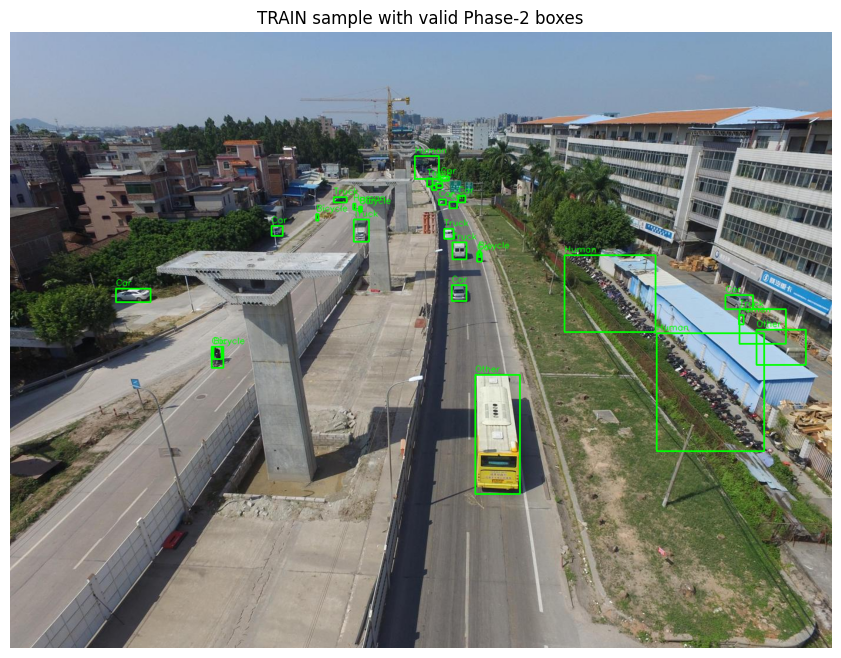

In [4]:
# ============================================================
# Cell 4: Inspect One VisDrone Annotation + Visualize Boxes
# Robust parsing + class-remap sanity check
# ============================================================

INSPECT_SPLIT = "train"

# Optional: set to a specific stem like "0000002_00005_d_0000014"
# If None, a random annotation file from the chosen split is used.
INSPECT_STEM = None

images_dir = DATASET_STRUCTURE[INSPECT_SPLIT]["images_dir"]
ann_dir = DATASET_STRUCTURE[INSPECT_SPLIT]["ann_dir"]

ann_files = sorted(ann_dir.glob("*.txt"))
assert len(ann_files) > 0, f"No annotation files found in: {ann_dir}"

if INSPECT_STEM is not None:
    sample_ann_file = ann_dir / f"{INSPECT_STEM}.txt"
    assert sample_ann_file.exists(), f"Annotation file not found: {sample_ann_file}"
else:
    rng = random.Random(SEED)
    sample_ann_file = rng.choice(ann_files)

sample_image_file = images_dir / f"{sample_ann_file.stem}.jpg"
assert sample_image_file.exists(), f"Image file not found: {sample_image_file}"

print(f"Inspecting annotation: {sample_ann_file.name}")
print(f"Corresponding image  : {sample_image_file.name}")

# ---- Load image ----
img = cv2.imread(str(sample_image_file))
assert img is not None, f"Failed to load image: {sample_image_file}"

img_vis = img.copy()
h_img, w_img, _ = img.shape
print(f"Image size: {w_img} x {h_img}")

# ---- Parse annotation file ----
with open(sample_ann_file, "r") as f:
    raw_lines = [l.strip() for l in f.readlines() if l.strip()]

print(f"Total annotated rows: {len(raw_lines)}\n")

drawn = 0
skip_reasons = defaultdict(int)
phase3_counts = defaultdict(int)

for idx, line in enumerate(raw_lines):
    parts = [p.strip() for p in line.split(",") if p.strip() != ""]

    if len(parts) != 8:
        skip_reasons["malformed_row"] += 1
        continue

    try:
        x, y, w, h, score, vd_cls, occ, trunc = map(int, parts)
    except ValueError:
        skip_reasons["non_integer_row"] += 1
        continue

    # ---- Skip ignored / unknown classes ----
    if vd_cls not in VISDRONE_TO_PHASE3:
        skip_reasons["unknown_visdrone_class"] += 1
        continue

    # ---- Validate box ----
    if w <= 0 or h <= 0:
        skip_reasons["non_positive_box"] += 1
        continue

    # Clip box to image bounds for visualization sanity
    x1 = max(0, x)
    y1 = max(0, y)
    x2 = min(w_img - 1, x + w)
    y2 = min(h_img - 1, y + h)

    if x2 <= x1 or y2 <= y1:
        skip_reasons["box_out_of_bounds_after_clip"] += 1
        continue

    phase3_cls = VISDRONE_TO_PHASE3[vd_cls]
    cls_name = PHASE3_CLASSES[phase3_cls]
    phase3_counts[cls_name] += 1

    print(
        f"Obj {idx:02d}: "
        f"VisDrone class={vd_cls} ({VISDRONE_CLASSES.get(vd_cls, 'UNKNOWN')}), "
        f"phase3={phase3_cls} ({cls_name}), "
        f"Box=(x={x}, y={y}, w={w}, h={h}), "
        f"occ={occ}, trunc={trunc}"
    )

    cv2.rectangle(
        img_vis,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    cv2.putText(
        img_vis,
        cls_name,
        (x1, max(15, y1 - 5)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1,
        cv2.LINE_AA
    )

    drawn += 1

print("\n=== Inspection Summary ===")
print(f"Drawn objects: {drawn}")
print(f"Skipped total: {sum(skip_reasons.values())}")

if skip_reasons:
    print("\nSkip reasons:")
    for reason, count in sorted(skip_reasons.items()):
        print(f"  {reason}: {count}")

if phase3_counts:
    print("\nPhase 3 class counts in this image:")
    for cls_name in PHASE3_CLASS_NAMES:
        print(f"  {cls_name:<8}: {phase3_counts.get(cls_name, 0)}")

# ---- Display image ----
img_vis = cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(img_vis)
plt.axis("off")
plt.title(f"{INSPECT_SPLIT.upper()} sample with valid Phase-2 boxes")
plt.show()

In [5]:
# ============================================================
# Cell 5: COCO Schema View + Enhanced Training Contract
# ============================================================

print("=== COCO Categories (Canonical) ===")
for cat in COCO_CATEGORIES:
    print(f"  id={cat['id']} | name={cat['name']}")
print("===================================\n")

# ---- Target input resolution for RF-DETR Nano ----
# Enhanced-training experiment: increase resolution to improve small-object performance.
TARGET_IMAGE_SIZE = 512

print(f"Target model input resolution: {TARGET_IMAGE_SIZE} x {TARGET_IMAGE_SIZE}\n")

# ---- Preprocessing policy (ENHANCED TRAINING) ----
PREPROCESSING_POLICY = {
    "image": {
        "target_size": TARGET_IMAGE_SIZE,
        "resize_enabled": True,
        "resize_method": "resize_longest_side_then_pad",
        "preserve_aspect_ratio": True,
        "pad_value": 0,
    },
    "boxes": {
        "scale_boxes": True,
        "clip_boxes_to_image": True,
        "filter_non_positive_boxes": True,
        "min_box_area_px_after_resize": 4,
    },
    "normalization": {
        "enabled": True,
        "mean": [0.485, 0.456, 0.406],
        "std":  [0.229, 0.224, 0.225],
    },
    "training_enhanced": {
        "small_object_focus": True,
        "higher_resolution_than_basic_training": True,
        "aggressive_random_crop": False,
        "heavy_downscale_augmentation": False,
        "notes": "Enhanced training uses 512 resolution to improve small-object detection."
    }
}

# ---- Experiment metadata ----
EXPERIMENT_METADATA = {
    "experiment_name": "enhanced-training",
    "based_on": "basic-training",
    "primary_change": "increase input resolution from 384 to 512",
    "expected_effect": "improved detection of small aerial objects at the cost of slower training/inference",
}

# ---- Compact metadata bundle for later cells ----
TRAINING_CONTRACT = {
    "num_classes": NUM_CLASSES,
    "class_names": PHASE3_CLASS_NAMES,
    "coco_categories": COCO_CATEGORIES,
    "target_image_size": TARGET_IMAGE_SIZE,
    "preprocessing_policy": PREPROCESSING_POLICY,
    "experiment_metadata": EXPERIMENT_METADATA,
}

print("=== Preprocessing Policy ===")
for section, cfg in PREPROCESSING_POLICY.items():
    print(f"{section}: {cfg}")
print("============================\n")

print("=== Experiment Metadata ===")
for k, v in EXPERIMENT_METADATA.items():
    print(f"{k}: {v}")
print("===========================\n")

print("=== Training Contract Summary ===")
print(f"num_classes       : {TRAINING_CONTRACT['num_classes']}")
print(f"class_names       : {TRAINING_CONTRACT['class_names']}")
print(f"target_image_size : {TRAINING_CONTRACT['target_image_size']}")
print(f"experiment_name   : {TRAINING_CONTRACT['experiment_metadata']['experiment_name']}")
print("=================================")

=== COCO Categories (Canonical) ===
  id=1 | name=Human
  id=2 | name=Bicycle
  id=3 | name=Car
  id=4 | name=Truck
  id=5 | name=Bus
  id=6 | name=Other

Target model input resolution: 512 x 512

=== Preprocessing Policy ===
image: {'target_size': 512, 'resize_enabled': True, 'resize_method': 'resize_longest_side_then_pad', 'preserve_aspect_ratio': True, 'pad_value': 0}
boxes: {'scale_boxes': True, 'clip_boxes_to_image': True, 'filter_non_positive_boxes': True, 'min_box_area_px_after_resize': 4}
normalization: {'enabled': True, 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225]}
training_enhanced: {'small_object_focus': True, 'higher_resolution_than_basic_training': True, 'aggressive_random_crop': False, 'heavy_downscale_augmentation': False, 'notes': 'Enhanced training uses 512 resolution to improve small-object detection.'}

=== Experiment Metadata ===
experiment_name: enhanced-training
based_on: basic-training
primary_change: increase input resolution from 384 to 512
expec

In [6]:
# ============================================================
# Cell 6: Reuse Existing COCO Exports
# ============================================================

COCO_OUTPUT_DIR = RFDETR_ROOT / "coco_annotations"

COCO_TRAIN_JSON   = COCO_OUTPUT_DIR / "visdrone_train_coco.json"
COCO_VAL_JSON     = COCO_OUTPUT_DIR / "visdrone_val_coco.json"
COCO_TESTDEV_JSON = COCO_OUTPUT_DIR / "visdrone_testdev_coco.json"

required_jsons = [COCO_TRAIN_JSON, COCO_VAL_JSON, COCO_TESTDEV_JSON]
missing = [str(p) for p in required_jsons if not p.exists()]
assert not missing, (
    "Missing required COCO export files:\n- " + "\n- ".join(missing) +
    "\nRun the conversion notebook first or copy the exports into coco_annotations/."
)

print("=== Reusing Existing COCO Exports ===")
print(f"Train   : {COCO_TRAIN_JSON}")
print(f"Val     : {COCO_VAL_JSON}")
print(f"Test-dev: {COCO_TESTDEV_JSON}")

# ---- Minimal validation helper ----
def inspect_coco_export(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        coco_json = json.load(f)

    categories = sorted(coco_json["categories"], key=lambda c: c["id"])
    cat_ids = [c["id"] for c in categories]
    cat_names = [c["name"] for c in categories]

    assert cat_ids == list(range(1, NUM_CLASSES + 1)), (
        f"Category ID mismatch in {json_path.name}: {cat_ids}"
    )
    assert cat_names == PHASE3_CLASS_NAMES, (
        f"Category name mismatch in {json_path.name}.\n"
        f"Expected: {PHASE3_CLASS_NAMES}\n"
        f"Got     : {cat_names}"
    )

    return {
        "images_total": len(coco_json["images"]),
        "annotations_total": len(coco_json["annotations"]),
        "output_json_path": str(json_path),
    }

COCO_EXPORT_SUMMARY = {
    "train": inspect_coco_export(COCO_TRAIN_JSON),
    "val": inspect_coco_export(COCO_VAL_JSON),
    "test-dev": inspect_coco_export(COCO_TESTDEV_JSON),
}

print("\n=== COCO Export Summary ===")
for split, summary in COCO_EXPORT_SUMMARY.items():
    print(f"\n[{split.upper()}]")
    print(f"  images_total      : {summary['images_total']}")
    print(f"  annotations_total : {summary['annotations_total']}")
    print(f"  output_json_path  : {summary['output_json_path']}")

=== Reusing Existing COCO Exports ===
Train   : F:\object-identification-uav-camera\phase-3\rfdetr\coco_annotations\visdrone_train_coco.json
Val     : F:\object-identification-uav-camera\phase-3\rfdetr\coco_annotations\visdrone_val_coco.json
Test-dev: F:\object-identification-uav-camera\phase-3\rfdetr\coco_annotations\visdrone_testdev_coco.json

=== COCO Export Summary ===

[TRAIN]
  images_total      : 6471
  annotations_total : 322368
  output_json_path  : F:\object-identification-uav-camera\phase-3\rfdetr\coco_annotations\visdrone_train_coco.json

[VAL]
  images_total      : 548
  annotations_total : 35251
  output_json_path  : F:\object-identification-uav-camera\phase-3\rfdetr\coco_annotations\visdrone_val_coco.json

[TEST-DEV]
  images_total      : 1610
  annotations_total : 71437
  output_json_path  : F:\object-identification-uav-camera\phase-3\rfdetr\coco_annotations\visdrone_testdev_coco.json


Loading COCO annotations from:
F:\object-identification-uav-camera\phase-3\rfdetr\coco_annotations\visdrone_train_coco.json

loading annotations into memory...
Done (t=0.84s)
creating index...
index created!
=== COCO Categories (Validated) ===
id=1 | name=Human
id=2 | name=Bicycle
id=3 | name=Car
id=4 | name=Truck
id=5 | name=Bus
id=6 | name=Other

=== Dataset Statistics ===
Images     : 6471
Annotations: 322368

=== Per-Class Annotation Counts ===
Human   : 88148
Bicycle : 27059
Car     : 160158
Truck   : 37831
Bus     : 3246
Other   : 5926

=== Annotation Integrity Checks Passed ===
All category_ids are valid
All image references are valid
All boxes have positive width/height



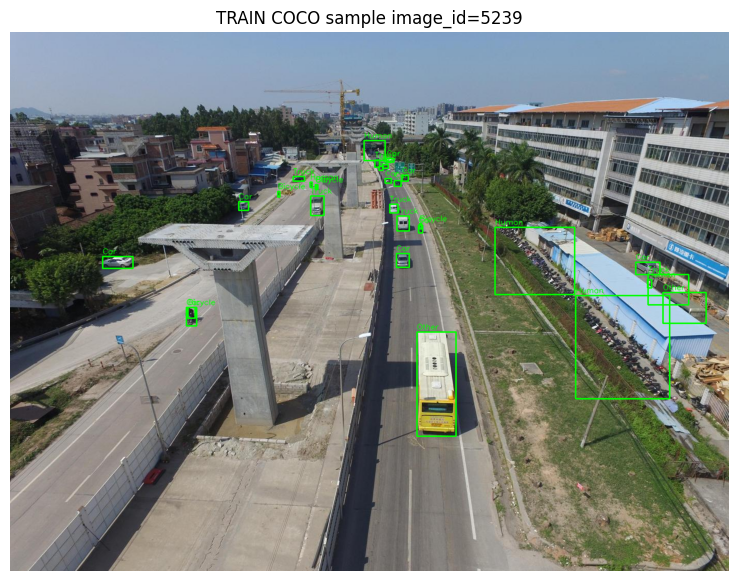

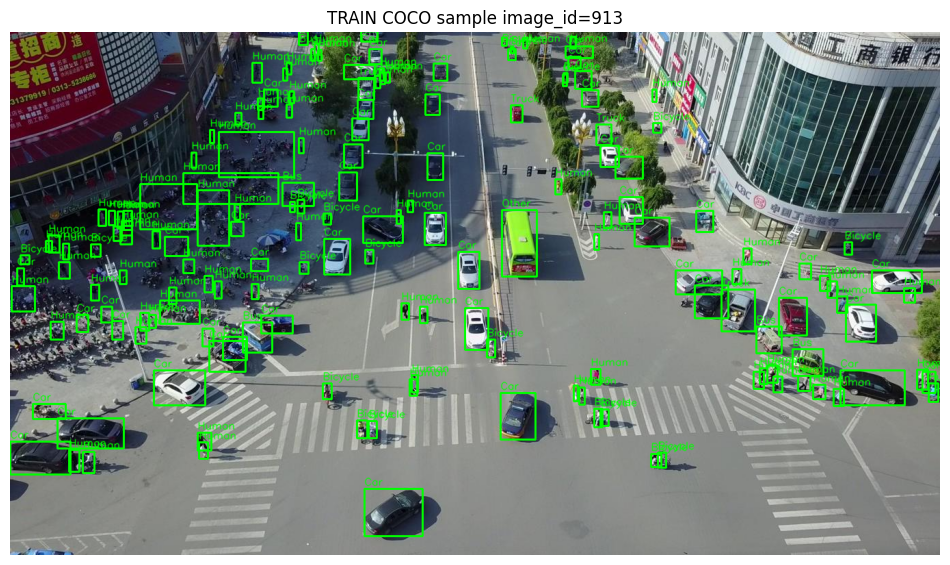

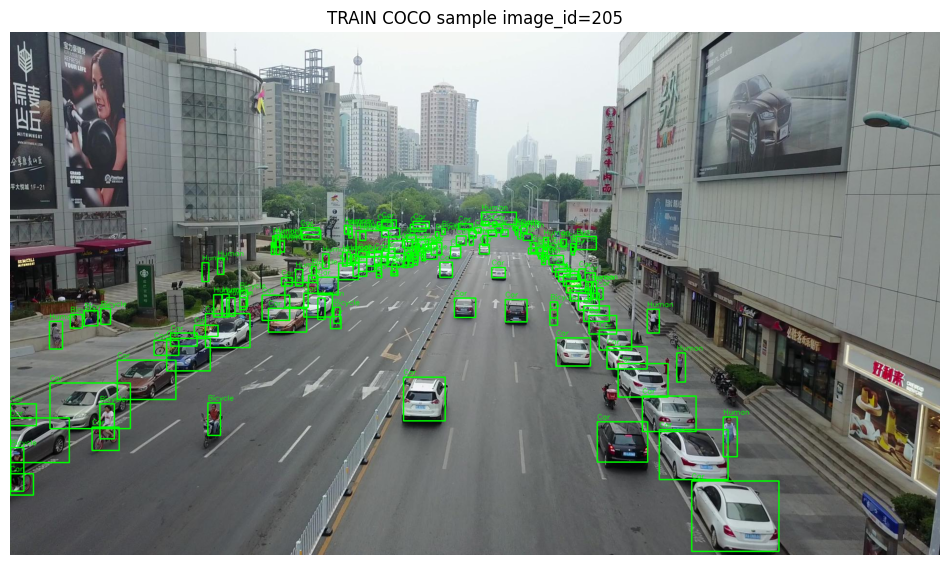

In [7]:
# ============================================================
# Cell 7: Validate COCO Output + Visual Sanity Check
# ============================================================

VALIDATE_SPLIT = "train"
COCO_JSON_PATH = COCO_OUTPUT_DIR / f"visdrone_{VALIDATE_SPLIT}_coco.json"
IMAGES_DIR = DATASET_STRUCTURE[VALIDATE_SPLIT]["images_dir"]

assert COCO_JSON_PATH.exists(), f"COCO JSON not found: {COCO_JSON_PATH}"
assert IMAGES_DIR.exists(), f"Images directory not found: {IMAGES_DIR}"

print(f"Loading COCO annotations from:\n{COCO_JSON_PATH}\n")

coco = COCO(str(COCO_JSON_PATH))

# ---- Verify categories against canonical metadata ----
cats = sorted(coco.loadCats(coco.getCatIds()), key=lambda c: c["id"])
exported_cat_ids = [c["id"] for c in cats]
exported_cat_names = [c["name"] for c in cats]

assert exported_cat_ids == list(range(1, NUM_CLASSES + 1)), (
    f"Exported category ids mismatch.\n"
    f"Expected: {list(range(1, NUM_CLASSES + 1))}\n"
    f"Got     : {exported_cat_ids}"
)

assert exported_cat_names == PHASE3_CLASS_NAMES, (
    f"Exported category names mismatch.\n"
    f"Expected: {PHASE3_CLASS_NAMES}\n"
    f"Got     : {exported_cat_names}"
)

print("=== COCO Categories (Validated) ===")
for c in cats:
    print(f"id={c['id']} | name={c['name']}")
print("===================================\n")

# ---- Dataset statistics ----
num_images = len(coco.getImgIds())
num_annotations = len(coco.getAnnIds())

print("=== Dataset Statistics ===")
print(f"Images     : {num_images}")
print(f"Annotations: {num_annotations}")
print("==========================\n")

# ---- Cross-check against conversion summary ----
if VALIDATE_SPLIT in COCO_EXPORT_SUMMARY:
    expected_images = COCO_EXPORT_SUMMARY[VALIDATE_SPLIT]["images_total"]
    expected_annotations = COCO_EXPORT_SUMMARY[VALIDATE_SPLIT]["annotations_total"]

    assert num_images == expected_images, (
        f"Image count mismatch for split '{VALIDATE_SPLIT}'. "
        f"Expected {expected_images}, got {num_images}"
    )
    assert num_annotations == expected_annotations, (
        f"Annotation count mismatch for split '{VALIDATE_SPLIT}'. "
        f"Expected {expected_annotations}, got {num_annotations}"
    )

# ---- Per-class annotation counts ----
print("=== Per-Class Annotation Counts ===")
for c in cats:
    cat_id = c["id"]
    ann_ids = coco.getAnnIds(catIds=[cat_id])
    print(f"{c['name']:<8}: {len(ann_ids)}")
print("==================================\n")

# ---- Strong annotation sanity checks ----
all_img_ids = set(coco.getImgIds())
all_anns = coco.loadAnns(coco.getAnnIds())

invalid_category_count = 0
invalid_image_ref_count = 0
invalid_box_count = 0

for ann in all_anns:
    if ann["category_id"] not in PHASE3_CLASSES:
        invalid_category_count += 1

    if ann["image_id"] not in all_img_ids:
        invalid_image_ref_count += 1

    x, y, w, h = ann["bbox"]
    if w <= 0 or h <= 0:
        invalid_box_count += 1

assert invalid_category_count == 0, f"Found {invalid_category_count} annotations with invalid category_id"
assert invalid_image_ref_count == 0, f"Found {invalid_image_ref_count} annotations with invalid image_id"
assert invalid_box_count == 0, f"Found {invalid_box_count} annotations with non-positive boxes"

print("=== Annotation Integrity Checks Passed ===")
print("All category_ids are valid")
print("All image references are valid")
print("All boxes have positive width/height")
print("==========================================\n")

# ---- Visualize reproducible random samples ----
NUM_SAMPLES = 3
rng = random.Random(SEED)
sample_img_ids = rng.sample(coco.getImgIds(), NUM_SAMPLES)

for img_id in sample_img_ids:
    img_info = coco.loadImgs(img_id)[0]
    img_path = IMAGES_DIR / img_info["file_name"]

    img = cv2.imread(str(img_path))
    assert img is not None, f"Failed to load image: {img_path}"
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ann_ids = coco.getAnnIds(imgIds=[img_id])
    anns = coco.loadAnns(ann_ids)

    for ann in anns:
        x, y, w, h = map(int, ann["bbox"])
        cls_name = class_id_to_name(ann["category_id"])

        cv2.rectangle(
            img,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )
        cv2.putText(
            img,
            cls_name,
            (x, max(15, y - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1,
            cv2.LINE_AA
        )

    plt.figure(figsize=(12, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{VALIDATE_SPLIT.upper()} COCO sample image_id={img_id}")
    plt.show()

In [8]:
# ============================================================
# Cell 8: Reuse Existing RF-DETR COCO Shim
# ============================================================

print("\n=== Reusing Existing RF-DETR COCO Shim ===\n")

# ---- RF-DETR expected COCO-style structure ----
COCO_TRAIN_IMG = RFDETR_ROOT / "train2017"
COCO_VAL_IMG   = RFDETR_ROOT / "val2017"
COCO_ANN_DIR   = RFDETR_ROOT / "annotations"

COCO_TRAIN_ANN = COCO_ANN_DIR / "instances_train2017.json"
COCO_VAL_ANN   = COCO_ANN_DIR / "instances_val2017.json"

required = [COCO_TRAIN_IMG, COCO_VAL_IMG, COCO_TRAIN_ANN, COCO_VAL_ANN]
missing = [str(p) for p in required if not p.exists()]

assert not missing, (
    "Missing RF-DETR COCO shim files/dirs:\n- " + "\n- ".join(missing) +
    "\nCreate the shim in the basic-training notebook first."
)

# ---- Verify image counts against dataset structure ----
train_src_count = DATASET_STRUCTURE["train"]["num_images"]
val_src_count   = DATASET_STRUCTURE["val"]["num_images"]

train_dst_count = len(list(COCO_TRAIN_IMG.glob("*.jpg")))
val_dst_count   = len(list(COCO_VAL_IMG.glob("*.jpg")))

assert train_dst_count == train_src_count, (
    f"TRAIN shim image count mismatch: expected {train_src_count}, got {train_dst_count}"
)
assert val_dst_count == val_src_count, (
    f"VAL shim image count mismatch: expected {val_src_count}, got {val_dst_count}"
)

# ---- Verify canonical categories inside annotation JSONs ----
def validate_shim_annotation(json_path, split_name):
    with open(json_path, "r", encoding="utf-8") as f:
        coco_json = json.load(f)

    exported_categories = sorted(coco_json["categories"], key=lambda c: c["id"])
    exported_cat_ids = [c["id"] for c in exported_categories]
    exported_cat_names = [c["name"] for c in exported_categories]

    assert exported_cat_ids == list(range(1, NUM_CLASSES + 1)), (
        f"{split_name} annotation ids mismatch: {exported_cat_ids}"
    )
    assert exported_cat_names == PHASE3_CLASS_NAMES, (
        f"{split_name} annotation names mismatch.\n"
        f"Expected: {PHASE3_CLASS_NAMES}\n"
        f"Got     : {exported_cat_names}"
    )

validate_shim_annotation(COCO_TRAIN_ANN, "TRAIN")
validate_shim_annotation(COCO_VAL_ANN, "VAL")

print("=== RF-DETR COCO shim validated ===")
print(f"Train images : {COCO_TRAIN_IMG} ({train_dst_count} files)")
print(f"Val images   : {COCO_VAL_IMG} ({val_dst_count} files)")
print(f"Annotations  : {COCO_ANN_DIR}")
print(f"Train ann    : {COCO_TRAIN_ANN.name}")
print(f"Val ann      : {COCO_VAL_ANN.name}")
print("Canonical categories verified in existing shim annotation JSONs.")


=== Reusing Existing RF-DETR COCO Shim ===

=== RF-DETR COCO shim validated ===
Train images : F:\object-identification-uav-camera\phase-3\rfdetr\train2017 (6471 files)
Val images   : F:\object-identification-uav-camera\phase-3\rfdetr\val2017 (548 files)
Annotations  : F:\object-identification-uav-camera\phase-3\rfdetr\annotations
Train ann    : instances_train2017.json
Val ann      : instances_val2017.json
Canonical categories verified in existing shim annotation JSONs.


In [9]:
# ============================================================
# Cell 9: Forward-Only RF-DETR Sanity Check
# NO training, NO backward pass
#
# Purpose:
# - Validate dataset + model compatibility
# - Catch class/count/path mismatches before training
# - Debug tensor / shape issues early
# ============================================================

import torch
from types import SimpleNamespace
from rfdetr import RFDETRNano
from rfdetr.datasets.coco import build as build_coco

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nRunning forward-only sanity check on device: {device}\n")

# ---- Verify shim paths exist ----
assert COCO_TRAIN_IMG.exists(), f"Missing COCO train image dir: {COCO_TRAIN_IMG}"
assert COCO_VAL_IMG.exists(), f"Missing COCO val image dir: {COCO_VAL_IMG}"
assert COCO_TRAIN_ANN.exists(), f"Missing COCO train annotation json: {COCO_TRAIN_ANN}"
assert COCO_VAL_ANN.exists(), f"Missing COCO val annotation json: {COCO_VAL_ANN}"

# ---- Initialize RF-DETR Nano with canonical class count ----
model = RFDETRNano(num_classes=NUM_CLASSES)

# Access underlying torch model
torch_model = model.model.model
torch_model.to(device)
torch_model.eval()

# ---- Minimal args object required by RF-DETR COCO dataset builder ----
args = SimpleNamespace(
    dataset_file="coco",
    coco_path=str(RFDETR_ROOT),
    square_resize_div_64=True,
    multi_scale=False,
    expanded_scales=False,
    do_random_resize_via_padding=False,
    patch_size=16,
    num_windows=2,
)

# ---- Build training dataset ----
dataset = build_coco(
    image_set="train",
    args=args,
    resolution=TARGET_IMAGE_SIZE
)

print(f"Dataset length: {len(dataset)}")
assert len(dataset) > 0, "Dataset is empty"

# ---- Fetch one sample ----
samples, targets = dataset[0]

print("\n=== Sample Inspection ===")
print(f"Sample tensor shape: {tuple(samples.shape)}")
print(f"Target keys        : {list(targets.keys())}")

assert "boxes" in targets, "Missing 'boxes' in targets"
assert "labels" in targets, "Missing 'labels' in targets"

num_target_boxes = len(targets["boxes"])
unique_labels = sorted(set(targets["labels"].cpu().numpy().tolist()))

print(f"Number of boxes    : {num_target_boxes}")
print(f"Unique label ids   : {unique_labels}")

assert num_target_boxes > 0, "Sample has zero target boxes"

# ---- Validate target labels ----
for label_id in unique_labels:
    assert 1 <= int(label_id) <= NUM_CLASSES, (
        f"Found out-of-range label_id={label_id}; expected within 1..{NUM_CLASSES}"
    )

# ---- Validate target boxes ----
boxes = targets["boxes"]
assert boxes.ndim == 2 and boxes.shape[1] == 4, (
    f"Expected target boxes shape [N, 4], got {tuple(boxes.shape)}"
)

# Batchify
samples = samples.unsqueeze(0).to(device)
targets = [{k: v.to(device) for k, v in targets.items()}]

# ---- Forward pass ONLY ----
with torch.no_grad():
    outputs = torch_model(samples, targets)

print("\nForward pass successful")
print("Output keys:", list(outputs.keys()))

assert "pred_logits" in outputs, "Missing 'pred_logits' in model outputs"
assert "pred_boxes" in outputs, "Missing 'pred_boxes' in model outputs"

pred_logits = outputs["pred_logits"]
pred_boxes = outputs["pred_boxes"]

print("\n=== Output Shape Inspection ===")
print(f"pred_logits shape: {tuple(pred_logits.shape)}")
print(f"pred_boxes shape : {tuple(pred_boxes.shape)}")

# Basic shape checks
assert pred_logits.ndim == 3, f"Expected pred_logits ndim=3, got {pred_logits.ndim}"
assert pred_boxes.ndim == 3, f"Expected pred_boxes ndim=3, got {pred_boxes.ndim}"
assert pred_boxes.shape[-1] == 4, f"Expected pred_boxes last dim = 4, got {pred_boxes.shape[-1]}"

print("\n=== Class Mapping Check ===")
print(f"Canonical num_classes : {NUM_CLASSES}")
print(f"Canonical class names : {PHASE3_CLASS_NAMES}")
print("Forward-only sanity check passed.")


Running forward-only sanity check on device: cuda

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights
loading annotations into memory...
Done (t=0.64s)
creating index...
index created!
Dataset length: 6471

=== Sample Inspection ===
Sample tensor shape: (3, 512, 512)
Target keys        : ['boxes', 'labels', 'image_id', 'area', 'iscrowd', 'orig_size', 'size']
Number of boxes    : 79
Unique label ids   : [1, 2, 3, 4, 5]

Forward pass successful
Output keys: ['pred_logits', 'pred_boxes', 'aux_outputs', 'enc_outputs']

=== Output Shape Inspection ===
pred_logits shape: (1, 300, 91)
pred_boxes shape : (1, 300, 4)

=== Class Mapping Check ===
Canonical num_classes : 6
Canonical class nam

In [10]:
# ============================================================
# Cell 10: Enhanced Training Config + Canonical Metadata Export
# ============================================================

import ast
import re
import subprocess
from datetime import datetime

assert torch.cuda.is_available(), "CUDA GPU is required."
print("GPU:", torch.cuda.get_device_name(0))

# ---- Required COCO shim paths ----
required = [COCO_TRAIN_IMG, COCO_VAL_IMG, COCO_TRAIN_ANN, COCO_VAL_ANN]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing COCO-layout files/dirs:\n- " + "\n- ".join(missing) +
        "\n\nExpected:\n"
        "rfdetr/train2017/*.jpg\n"
        "rfdetr/val2017/*.jpg\n"
        "rfdetr/annotations/instances_train2017.json\n"
        "rfdetr/annotations/instances_val2017.json\n"
    )

# ---- Output dirs ----
OUT_ROOT = RFDETR_ROOT / "checkpoints"
LOG_DIR  = RFDETR_ROOT / "logs"
META_DIR = RFDETR_ROOT / "run_metadata"

OUT_ROOT.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
META_DIR.mkdir(parents=True, exist_ok=True)

# ---- Experiment identity ----
EXPERIMENT_NAME = "enhanced-training"

# ---- Enhanced training config ----
# Safer 512 config for limited-VRAM GPUs:
# - batch_size=1 reduces per-step memory
# - grad_accum_steps=16 preserves effective batch size
TRAIN_CONFIG = {
    "dataset_file": "coco",
    "dataset_dir": str(RFDETR_ROOT),
    "coco_path": str(RFDETR_ROOT),
    "device": "cuda",

    "num_classes": NUM_CLASSES,
    "input_size": TARGET_IMAGE_SIZE,
    "resolution": TARGET_IMAGE_SIZE,

    "batch_size": 1,
    "grad_accum_steps": 16,   # effective batch = 16

    "epochs": 40,
    "lr": 1e-4,

    "amp": True,
    "use_ema": True,
    "do_benchmark": False,
    "fp16_eval": False,

    "early_stopping": True,
    "early_stopping_patience": 5,

    # Windows-safe default
    "num_workers": 0,

    "checkpoint_interval": 1,
    "tensorboard": True,
}

print("\n=== Training Config ===")
for k, v in TRAIN_CONFIG.items():
    print(f"{k}: {v}")

# ---- Save canonical metadata for future audit/debug ----
RUN_CANONICAL_METADATA = {
    "created_at": datetime.now().isoformat(),
    "experiment_name": EXPERIMENT_NAME,
    "based_on": "basic-training",
    "num_classes": NUM_CLASSES,
    "class_id_to_name": PHASE3_CLASSES,
    "class_names_ordered": PHASE3_CLASS_NAMES,
    "coco_categories": COCO_CATEGORIES,
    "target_image_size": TARGET_IMAGE_SIZE,
    "train_config": TRAIN_CONFIG,
    "notes": {
        "primary_change_1": "increase input resolution from 384 to 512",
        "primary_change_2": "increase training length from 20 epochs to 40 epochs",
        "primary_change_3": "reduce batch size to 1 for 8GB-class GPUs",
        "motivation": "improve small-object detection while keeping dataset and taxonomy fixed"
    }
}

CANONICAL_METADATA_PATH = META_DIR / f"{EXPERIMENT_NAME}_canonical_training_metadata.json"
with open(CANONICAL_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(RUN_CANONICAL_METADATA, f, indent=2)

print(f"\nSaved canonical metadata to:\n{CANONICAL_METADATA_PATH}")

GPU: NVIDIA GeForce RTX 3070 Ti

=== Training Config ===
dataset_file: coco
dataset_dir: F:\object-identification-uav-camera\phase-3\rfdetr
coco_path: F:\object-identification-uav-camera\phase-3\rfdetr
device: cuda
num_classes: 6
input_size: 512
resolution: 512
batch_size: 1
grad_accum_steps: 16
epochs: 40
lr: 0.0001
amp: True
use_ema: True
do_benchmark: False
fp16_eval: False
early_stopping: True
early_stopping_patience: 5
num_workers: 0
checkpoint_interval: 1
tensorboard: True

Saved canonical metadata to:
F:\object-identification-uav-camera\phase-3\rfdetr\run_metadata\enhanced-training_canonical_training_metadata.json


In [11]:
# ============================================================
# Cell 11: RF-DETR Enhanced Training Smoke Test (GPU, Minimal)
# ============================================================

from rfdetr import RFDETRNano

print("\nStarting RF-DETR enhanced-training smoke test...\n")

assert torch.cuda.is_available(), "CUDA is not available — training requires GPU"

# ---- Small one-epoch smoke config ----
SMOKE_CONFIG = dict(TRAIN_CONFIG)
SMOKE_CONFIG.update({
    "epochs": 1,
    "batch_size": 1,
    "grad_accum_steps": 1,
    "use_ema": False,
    "output_dir": str(OUT_ROOT / "smoke_test_enhanced_training"),
})

Path(SMOKE_CONFIG["output_dir"]).mkdir(parents=True, exist_ok=True)

print("=== Smoke Test Config ===")
for k, v in SMOKE_CONFIG.items():
    print(f"{k}: {v}")

print("\nSmoke test purpose:")
print("- validate enhanced-training config")
print("- validate 512-resolution training path")
print("- validate model/dataset compatibility before full run")

# ---- Initialize model with canonical class count ----
model = RFDETRNano(num_classes=NUM_CLASSES)

# ---- Train (very small run) ----
model.train(**SMOKE_CONFIG)

print("\nEnhanced-training smoke test completed successfully.")


Starting RF-DETR enhanced-training smoke test...

=== Smoke Test Config ===
dataset_file: coco
dataset_dir: F:\object-identification-uav-camera\phase-3\rfdetr
coco_path: F:\object-identification-uav-camera\phase-3\rfdetr
device: cuda
num_classes: 6
input_size: 512
resolution: 512
batch_size: 1
grad_accum_steps: 1
epochs: 1
lr: 0.0001
amp: True
use_ema: False
do_benchmark: False
fp16_eval: False
early_stopping: True
early_stopping_patience: 5
num_workers: 0
checkpoint_interval: 1
tensorboard: True
output_dir: F:\object-identification-uav-camera\phase-3\rfdetr\checkpoints\smoke_test_enhanced_training

Smoke test purpose:
- validate enhanced-training config
- validate 512-resolution training path
- validate model/dataset compatibility before full run
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loa

In [12]:
# ============================================================
# Cell 12: Full RF-DETR Enhanced Training Launch
# Minimal live status output
# ============================================================

import sys
import os
import time
import subprocess
import re
import json
from IPython.display import display, update_display, HTML

assert torch.cuda.is_available(), "CUDA GPU is required."
print("GPU:", torch.cuda.get_device_name(0))

run_name = time.strftime("enhanced_training_%Y%m%d_%H%M%S")
output_dir = OUT_ROOT / run_name
output_dir.mkdir(parents=True, exist_ok=True)

log_path = LOG_DIR / f"{run_name}.log"
run_metadata_path = META_DIR / f"{run_name}_metadata.json"

FULL_TRAIN_CONFIG = dict(TRAIN_CONFIG)
FULL_TRAIN_CONFIG["output_dir"] = str(output_dir)

# ---- Save run metadata for this specific run ----
run_metadata = {
    "run_name": run_name,
    "experiment_name": "enhanced-training",
    "based_on": "basic-training",
    "log_path": str(log_path),
    "output_dir": str(output_dir),
    "seed": SEED,
    "num_classes": NUM_CLASSES,
    "class_names_ordered": PHASE3_CLASS_NAMES,
    "class_id_to_name": PHASE3_CLASSES,
    "target_image_size": TARGET_IMAGE_SIZE,
    "train_config": FULL_TRAIN_CONFIG,
    "notes": {
        "primary_change_1": "increase input resolution from 384 to 512",
        "primary_change_2": "increase training length from 20 epochs to 40 epochs",
        "primary_change_3": "reduce batch size to 1 for lower-VRAM GPUs"
    }
}
with open(run_metadata_path, "w", encoding="utf-8") as f:
    json.dump(run_metadata, f, indent=2)

print("Logs        ->", log_path)
print("Checkpoints ->", output_dir)
print("Metadata    ->", run_metadata_path)

# ---- Write a runner script so stdout/stderr can be fully captured ----
runner_path = output_dir / "_runner.py"
runner_path.write_text(
    "import json\n"
    "import torch\n"
    "from rfdetr import RFDETRNano\n"
    f"NUM_CLASSES = {NUM_CLASSES}\n"
    f"PHASE3_CLASS_NAMES = {repr(PHASE3_CLASS_NAMES)}\n"
    f"PHASE3_CLASSES = {repr(PHASE3_CLASSES)}\n"
    f"TARGET_IMAGE_SIZE = {TARGET_IMAGE_SIZE}\n"
    f"SEED = {SEED}\n"
    f"train_config = {repr(FULL_TRAIN_CONFIG)}\n"
    "print('=== Runner Startup ===', flush=True)\n"
    "print('Experiment       : enhanced-training', flush=True)\n"
    "print('Based on         : basic-training', flush=True)\n"
    "print('CUDA available   :', torch.cuda.is_available(), flush=True)\n"
    "if torch.cuda.is_available():\n"
    "    print('GPU              :', torch.cuda.get_device_name(0), flush=True)\n"
    "print('NUM_CLASSES      :', NUM_CLASSES, flush=True)\n"
    "print('TARGET_IMAGE_SIZE:', TARGET_IMAGE_SIZE, flush=True)\n"
    "print('SEED             :', SEED, flush=True)\n"
    "print('PHASE3_CLASS_NAMES:', PHASE3_CLASS_NAMES, flush=True)\n"
    "print('TRAIN_CONFIG     :', train_config, flush=True)\n"
    "print('======================', flush=True)\n"
    "model = RFDETRNano(num_classes=NUM_CLASSES)\n"
    "model.train(**train_config)\n"
)

# ---- Launch training ----
env_vars = dict(os.environ)
env_vars["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

with open(log_path, "w", encoding="utf-8", buffering=1) as logf:
    proc = subprocess.Popen(
        [sys.executable, "-u", str(runner_path)],
        stdout=logf,
        stderr=subprocess.STDOUT,
        cwd=str(output_dir),
        env=env_vars,
        text=True,
    )

# ---- Minimal live status parsing ----
EPOCHS = FULL_TRAIN_CONFIG["epochs"]

epoch_re = re.compile(r"Epoch:\s*\[(\d+)\]\s*\[\s*(\d+)\s*/\s*(\d+)\s*\]")
test_re  = re.compile(r"Test:\s*\[\s*(\d+)\s*/\s*(\d+)\s*\]")
error_re = re.compile(r"(Traceback|CUDA out of memory|OutOfMemoryError|RuntimeError)")

offset = 0
current_epoch = None
current_iter = None
current_iter_total = None
val_iter = None
val_iter_total = None
status_text = "Starting subprocess..."
last_gpu_poll = 0
gpu_text = "GPU status unavailable"
last_render = ""
error_seen = None

display_id = "enhanced_training_status"
display(HTML("<pre>Starting training monitor...</pre>"), display_id=display_id)

def query_gpu():
    try:
        out = subprocess.check_output(
            [
                "nvidia-smi",
                "--query-gpu=utilization.gpu,memory.used,memory.total",
                "--format=csv,noheader,nounits",
            ],
            text=True
        ).strip()
        util, mem_used, mem_total = [x.strip() for x in out.split(",")]
        return f"GPU {util}% | VRAM {mem_used}/{mem_total} MiB"
    except Exception:
        return "GPU status unavailable"

def render_status():
    epoch_line = (
        f"Epoch      : {current_epoch + 1}/{EPOCHS}"
        if current_epoch is not None else
        f"Epoch      : waiting"
    )
    iter_line = (
        f"Train iter : {current_iter}/{current_iter_total}"
        if current_iter is not None and current_iter_total is not None else
        f"Train iter : waiting"
    )
    val_line = (
        f"Val iter   : {val_iter}/{val_iter_total}"
        if val_iter is not None and val_iter_total is not None else
        f"Val iter   : -"
    )
    err_line = f"Error      : {error_seen}" if error_seen else "Error      : none"
    return (
        f"Run        : {run_name}\n"
        f"{epoch_line}\n"
        f"{iter_line}\n"
        f"{val_line}\n"
        f"Status     : {status_text}\n"
        f"{gpu_text}\n"
        f"{err_line}\n"
        f"Log        : {log_path}"
    )

while proc.poll() is None:
    time.sleep(1.0)

    chunk = ""
    if log_path.exists():
        with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
            f.seek(offset)
            chunk = f.read()
            offset = f.tell()

    if chunk:
        for line in chunk.splitlines():
            m = epoch_re.search(line)
            if m:
                current_epoch = int(m.group(1))
                current_iter = int(m.group(2))
                current_iter_total = int(m.group(3))
                val_iter = None
                val_iter_total = None
                status_text = "Training"
                continue

            t = test_re.search(line)
            if t:
                val_iter = int(t.group(1))
                val_iter_total = int(t.group(2))
                status_text = "Validation"
                continue

            if error_re.search(line):
                error_seen = line.strip()
                status_text = "Error detected"

    now = time.time()
    if now - last_gpu_poll > 5:
        gpu_text = query_gpu()
        last_gpu_poll = now

    rendered = render_status()
    if rendered != last_render:
        update_display(HTML(f"<pre>{rendered}</pre>"), display_id=display_id)
        last_render = rendered

# ---- Final status update ----
if proc.returncode == 0:
    status_text = "Finished successfully"
else:
    status_text = f"Exited with code {proc.returncode}"

gpu_text = query_gpu()
rendered = render_status()
update_display(HTML(f"<pre>{rendered}</pre>"), display_id=display_id)

print("\nTraining process exited with code:", proc.returncode)
print("Log file:", log_path)
print("Output dir:", output_dir)
print("Run metadata:", run_metadata_path)

GPU: NVIDIA GeForce RTX 3070 Ti
Logs        -> F:\object-identification-uav-camera\phase-3\rfdetr\logs\enhanced_training_20260310_015359.log
Checkpoints -> F:\object-identification-uav-camera\phase-3\rfdetr\checkpoints\enhanced_training_20260310_015359
Metadata    -> F:\object-identification-uav-camera\phase-3\rfdetr\run_metadata\enhanced_training_20260310_015359_metadata.json



Training process exited with code: 0
Log file: F:\object-identification-uav-camera\phase-3\rfdetr\logs\enhanced_training_20260310_015359.log
Output dir: F:\object-identification-uav-camera\phase-3\rfdetr\checkpoints\enhanced_training_20260310_015359
Run metadata: F:\object-identification-uav-camera\phase-3\rfdetr\run_metadata\enhanced_training_20260310_015359_metadata.json


In [13]:
# ============================================================
# Cell 13: Post-Run Log Parsing + Class Audit
# ============================================================

assert log_path.exists(), f"Log file not found: {log_path}"

with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
    log_text = f.read()

tail_lines = log_text.splitlines()[-500:]

print("\n===== Log Audit =====")

# ---- Process status ----
if "Training process exited with code:" in log_text:
    print("Notebook launch status was recorded above.")
if "Traceback" in log_text:
    print("WARNING: Training log contains a traceback / failure.")
else:
    print("No traceback detected in log tail.")

# ---- Look for suspicious class-count leakage ----
if "num_classes=90" in log_text or "num_classes': 90" in log_text or '"num_classes": 90' in log_text:
    print("WARNING: Found evidence of num_classes=90 in the training log.")
else:
    print("No explicit num_classes=90 string found in log.")

# ---- Look for unexpected class names ----
unexpected_names = ["Motorcycle", "motorcycle", "person"]
found_unexpected = [name for name in unexpected_names if name in log_text]

if found_unexpected:
    print("WARNING: Found unexpected class-name strings in log:", found_unexpected)
else:
    print("No obvious unexpected default COCO class-name strings found in log.")

print("\n===== COCO EVAL (from log) =====")
capture = False
found_eval = False
for ln in tail_lines:
    if "IoU metric: bbox" in ln:
        capture = True
        found_eval = True
    if capture:
        s = ln.rstrip()
        if s:
            print(s)

if not found_eval:
    print("No completed COCO evaluation block found in log.")

# ---- Parse final 'Test results:' object if present ----
test_results = None
for ln in reversed(tail_lines):
    if ln.strip().startswith("Test results:"):
        rhs = ln.split("Test results:", 1)[1].strip()
        try:
            test_results = ast.literal_eval(rhs)
        except Exception:
            test_results = None
        break

if test_results:
    print("\n===== Key Test Results =====")
    for k in ["class_error", "loss", "loss_ce", "loss_bbox", "loss_giou"]:
        if k in test_results:
            print(f"{k}: {test_results[k]}")

    # ---- Inspect results_json class_map names if present ----
    results_json = test_results.get("results_json", {})
    class_map = results_json.get("class_map", [])

    if class_map:
        exported_result_classes = [row.get("class") for row in class_map]
        print("\n===== Result Class Names =====")
        print(exported_result_classes)

        expected_set = set(PHASE3_CLASS_NAMES + ["all"])
        exported_set = set(exported_result_classes)

        if exported_set != expected_set:
            print("\nWARNING: Result class names do not exactly match canonical class names.")
            print("Expected:", sorted(expected_set))
            print("Got     :", sorted(exported_set))
        else:
            print("\nResult class names match canonical mapping.")
else:
    print("\nNo parsable 'Test results:' block found in log.")

# ---- Show latest checkpoints ----
ckpts = sorted(output_dir.glob("*.pth"), key=lambda p: p.stat().st_mtime)
if ckpts:
    print("\n===== Latest Checkpoints =====")
    for p in ckpts[-10:]:
        print(" -", p.name)
else:
    print("\nNo checkpoints found in output_dir.")


===== Log Audit =====
No traceback detected in log tail.

===== COCO EVAL (from log) =====
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.238
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.415
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.233
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.117
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.358
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.571
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.097
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.259
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.352
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.223
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.504
 Average Re

In [14]:
# ============================================================
# Cell 14: Pin Current Run Checkpoints to models/enhanced-training
# ============================================================

import shutil
from pathlib import Path

assert output_dir.exists(), f"Run output_dir does not exist: {output_dir}"

MODELS_ROOT = RFDETR_ROOT / "models"
ENHANCED_MODELS_DIR = MODELS_ROOT / "enhanced-training"
ENHANCED_MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ---- Candidate checkpoints from training ----
best_ema   = output_dir / "checkpoint_best_ema.pth"
best_total = output_dir / "checkpoint_best_total.pth"
latest     = output_dir / "checkpoint.pth"

print("=== Checkpoint Availability ===")
print("best_ema   :", best_ema.exists(), best_ema)
print("best_total :", best_total.exists(), best_total)
print("latest     :", latest.exists(), latest)

if not best_ema.exists() and not latest.exists():
    raise FileNotFoundError(
        "No usable checkpoints found in this run output directory.\n"
        "Expected at least one of:\n"
        f"- {best_ema}\n"
        f"- {latest}"
    )

# ---- Stable destination names ----
dst_best_ema   = ENHANCED_MODELS_DIR / "visdrone_rfdetr_nano_best_ema.pth"
dst_latest     = ENHANCED_MODELS_DIR / "visdrone_rfdetr_nano_latest_resume.pth"
dst_best_total = ENHANCED_MODELS_DIR / "visdrone_rfdetr_nano_best_total.pth"

# ---- Copy available checkpoints ----
if best_ema.exists():
    shutil.copy2(best_ema, dst_best_ema)
    print("[COPY] Best EMA      ->", dst_best_ema)
else:
    print("[WARN] best_ema checkpoint missing; not copied")

if latest.exists():
    shutil.copy2(latest, dst_latest)
    print("[COPY] Latest resume ->", dst_latest)
else:
    print("[WARN] latest checkpoint missing; not copied")

if best_total.exists():
    shutil.copy2(best_total, dst_best_total)
    print("[COPY] Best total    ->", dst_best_total)
else:
    print("[WARN] checkpoint_best_total.pth not found; not copied")

# ---- Save metadata for this pinned model set ----
enhanced_training_metadata = {
    "source_run_name": run_name,
    "source_output_dir": str(output_dir),
    "source_log_path": str(log_path),
    "experiment_name": "enhanced-training",
    "based_on": "basic-training",
    "num_classes": NUM_CLASSES,
    "class_names_ordered": PHASE3_CLASS_NAMES,
    "target_image_size": TARGET_IMAGE_SIZE,
    "train_config": FULL_TRAIN_CONFIG,
    "test_results": test_results if "test_results" in globals() and test_results is not None else None,
    "pinned_files": {
        "best_ema": str(dst_best_ema) if best_ema.exists() else None,
        "latest_resume": str(dst_latest) if latest.exists() else None,
        "best_total": str(dst_best_total) if best_total.exists() else None,
    },
}

metadata_path = ENHANCED_MODELS_DIR / "metadata.json"
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(enhanced_training_metadata, f, indent=2)

print("\nPinned checkpoints summary:")
print("  Best EMA      :", str(dst_best_ema) if best_ema.exists() else None)
print("  Latest resume :", str(dst_latest) if latest.exists() else None)
print("  Best total    :", str(dst_best_total) if best_total.exists() else None)
print("  Metadata      :", metadata_path)

=== Checkpoint Availability ===
best_ema   : True F:\object-identification-uav-camera\phase-3\rfdetr\checkpoints\enhanced_training_20260310_015359\checkpoint_best_ema.pth
best_total : True F:\object-identification-uav-camera\phase-3\rfdetr\checkpoints\enhanced_training_20260310_015359\checkpoint_best_total.pth
latest     : True F:\object-identification-uav-camera\phase-3\rfdetr\checkpoints\enhanced_training_20260310_015359\checkpoint.pth
[COPY] Best EMA      -> F:\object-identification-uav-camera\phase-3\rfdetr\models\enhanced-training\visdrone_rfdetr_nano_best_ema.pth
[COPY] Latest resume -> F:\object-identification-uav-camera\phase-3\rfdetr\models\enhanced-training\visdrone_rfdetr_nano_latest_resume.pth
[COPY] Best total    -> F:\object-identification-uav-camera\phase-3\rfdetr\models\enhanced-training\visdrone_rfdetr_nano_best_total.pth

Pinned checkpoints summary:
  Best EMA      : F:\object-identification-uav-camera\phase-3\rfdetr\models\enhanced-training\visdrone_rfdetr_nano_best_

In [15]:
# ============================================================
# Cell 15: Inspect Suspicious Log Lines
# ============================================================

assert log_path.exists(), f"Log file not found: {log_path}"

patterns = [
    "num_classes=90",
    "motorcycle",
    "Motorcycle",
    "person",
    "class_names",
    "OutOfMemoryError",
    "CUDA out of memory",
    "Traceback",
]

with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

matches = []
for i, line in enumerate(lines, start=1):
    lower = line.lower()
    for p in patterns:
        if p.lower() in lower:
            matches.append((i, line.rstrip()))
            break

print("=== Suspicious Log Matches ===")
if not matches:
    print("No matches found.")
else:
    for line_no, text in matches[:150]:
        print(f"{line_no}: {text}")

=== Suspicious Log Matches ===
9: PHASE3_CLASS_NAMES: ['Human', 'Bicycle', 'Car', 'Truck', 'Bus', 'Other']
288: Namespace(num_classes=90, grad_accum_steps=16, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=1, weight_decay=0.0001, epochs=40, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-nano.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_small', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', out_feature_indexes=[3, 6, 9, 12], freeze_encoder=False, layer_norm=True, rms_norm=False, backbone_lora=False, force_no_pretrain=False, dec_layers=2, dim_feedforward=2048, hidden_dim=256, sa_nheads=8, ca_nheads=16, num_queries=300, group_detr=13, two_stage=True, projector_scale=['P4'], lite_refpoi

Image: F:\object-identification-uav-camera\phase-3\visdrone-dataset-rgb\val\images\0000194_00800_d_0000123.jpg
Loading model from checkpoint (this happens once per kernel)...
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


Loaded checkpoint: visdrone_rfdetr_nano_best_ema.pth
Device: cuda
Canonical classes: ['Human', 'Bicycle', 'Car', 'Truck', 'Bus', 'Other']
Detections: 34 (threshold=0.3)


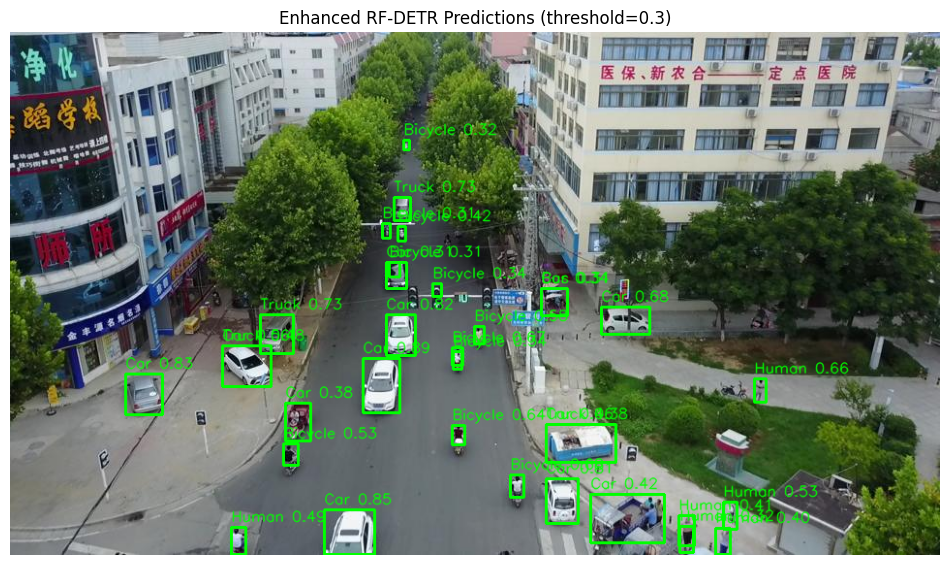

In [16]:
# ============================================================
# Cell 16: Inference Demo Cell --> Load pinned model + predict on one image + visualize
# ============================================================

from pathlib import Path
import random
import torch
import cv2
import matplotlib.pyplot as plt
from rfdetr import RFDETRNano

# -----------------------------
# 1) Configure inputs
# -----------------------------
# Option A: set an explicit image path:
IMAGE_PATH = None  # e.g. r"C:\path\to\your\image.jpg"

# Option B: pick a random image from the VisDrone val set if IMAGE_PATH is None
DEFAULT_IMAGE_DIR = DATASET_STRUCTURE["val"]["images_dir"]

# Checkpoint: use the pinned BEST EMA checkpoint from enhanced-training
CKPT_PATH = RFDETR_ROOT / "models" / "enhanced-training" / "visdrone_rfdetr_nano_best_ema.pth"

# Fallback to latest resume if best EMA is unavailable
FALLBACK_CKPT_PATH = RFDETR_ROOT / "models" / "enhanced-training" / "visdrone_rfdetr_nano_latest_resume.pth"

# Prediction threshold
THRESHOLD = 0.30

# -----------------------------
# 2) Resolve image path
# -----------------------------
if IMAGE_PATH is None:
    assert DEFAULT_IMAGE_DIR.exists(), f"Default image dir not found: {DEFAULT_IMAGE_DIR}"
    imgs = list(DEFAULT_IMAGE_DIR.glob("*.jpg"))
    assert len(imgs) > 0, f"No images found in: {DEFAULT_IMAGE_DIR}"
    rng = random.Random(SEED)
    image_path = str(rng.choice(imgs))
else:
    image_path = str(IMAGE_PATH)

print("Image:", image_path)

# -----------------------------
# 3) Resolve checkpoint path
# -----------------------------
if CKPT_PATH.exists():
    resolved_ckpt = CKPT_PATH
elif FALLBACK_CKPT_PATH.exists():
    resolved_ckpt = FALLBACK_CKPT_PATH
else:
    raise FileNotFoundError(
        "No enhanced-training checkpoint found.\n"
        f"Tried:\n- {CKPT_PATH}\n- {FALLBACK_CKPT_PATH}"
    )

device = "cuda" if torch.cuda.is_available() else "cpu"

# Cache the model so repeated runs don't reload weights
global _RFD_MODEL, _RFD_CKPT
if "_RFD_MODEL" not in globals() or "_RFD_CKPT" not in globals() or _RFD_CKPT != str(resolved_ckpt):
    print("Loading model from checkpoint (this happens once per kernel)...")
    _RFD_MODEL = RFDETRNano(num_classes=NUM_CLASSES, pretrain_weights=str(resolved_ckpt))
    _RFD_CKPT = str(resolved_ckpt)

# Move underlying torch model to device
_RFD_MODEL.model.model.to(device)
_RFD_MODEL.model.model.eval()

print("Loaded checkpoint:", resolved_ckpt.name)
print("Device:", device)
print("Canonical classes:", PHASE3_CLASS_NAMES)

# -----------------------------
# 4) Predict
# -----------------------------
det = _RFD_MODEL.predict(image_path, threshold=THRESHOLD)

boxes = det.xyxy
scores = det.confidence
class_ids = det.class_id

print(f"Detections: {len(boxes)} (threshold={THRESHOLD})")

# -----------------------------
# 5) Visualize
# -----------------------------
img = cv2.imread(image_path)
if img is None:
    raise FileNotFoundError(f"Could not read image: {image_path}")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

for box, score, cls in zip(boxes, scores, class_ids):
    x1, y1, x2, y2 = map(int, box.tolist())
    cls = int(cls)

    label = class_id_to_name(cls)
    text = f"{label} {float(score):.2f}"

    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(
        img_rgb,
        text,
        (x1, max(15, y1 - 6)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1,
        cv2.LINE_AA
    )

plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"Enhanced RF-DETR Predictions (threshold={THRESHOLD})")
plt.show()